In [44]:
# -------------------------------------------------------------------------
# DATOS CRUDOS
# -------------------------------------------------------------------------

# Núcleos evaluados (Eje X)
nucleos = [1, 4, 8, 12, 16, 20]

tiempos_madrid = [
    0.164,  # Secuencial
    0.196,  # NP=4
    0.176,  # NP=8
    0.200,  # NP=12
    0.222,  # NP=16
    0.238,  # NP=20
]

tiempos_cyl = [
    0.052,  # Secuencial
    0.050,  # NP=4
    0.066,  # NP=8
    0.064,  # NP=12
    0.082,  # NP=16
    0.086,  # NP=20
]

tiempos_cataluna = [
    578.112,  # Secuencial
    203.74, # NP=4
    96.086, # NP=8
    75.346, # NP=12
    66.886, # NP=16
    57.414, # NP=20
]

tiempos_andalucia = [
    683.188,  # Secuencial
    238.256,# NP=4
    136.76, # NP=8
    113.864,# NP=12
    101.248,# NP=16
    94.948, # NP=20
]

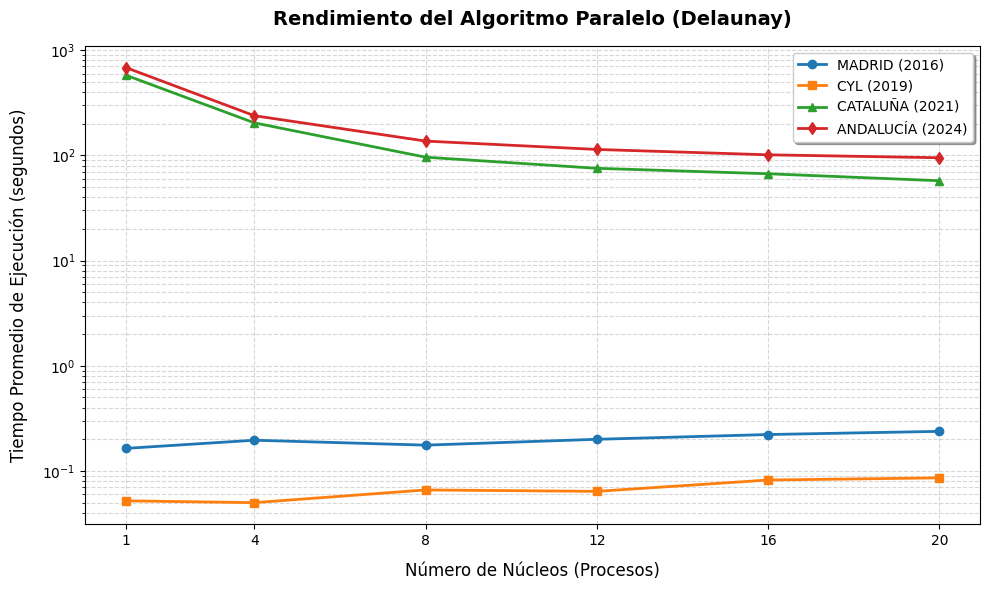

In [45]:
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# GRÁFICA CON TODOS LOS RESULTADOS
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Líneas de cada conjunto
plt.plot(nucleos, tiempos_madrid, marker='o', linewidth=2, label='MADRID (2016)')
plt.plot(nucleos, tiempos_cyl, marker='s', linewidth=2, label='CYL (2019)')
plt.plot(nucleos, tiempos_cataluna, marker='^', linewidth=2, label='CATALUÑA (2021)')
plt.plot(nucleos, tiempos_andalucia, marker='d', linewidth=2, label='ANDALUCÍA (2024)')

# Ejes y título
plt.title('Rendimiento del Algoritmo Paralelo (Delaunay)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de Núcleos (Procesos)', fontsize=12, labelpad=10)
plt.ylabel('Tiempo Promedio de Ejecución (segundos)', fontsize=12, labelpad=10)

# Eje Y: Escala logarítmica
plt.yscale('log')

# Eje X: los núcleos dados
plt.xticks(nucleos)

# Cuadrícula y leyenda
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend(loc='best', fontsize=10, frameon=True, shadow=True)

# Guardar imagen
plt.tight_layout()
plt.savefig('grafica_rendimiento_delaunay.png', dpi=300)
plt.show()

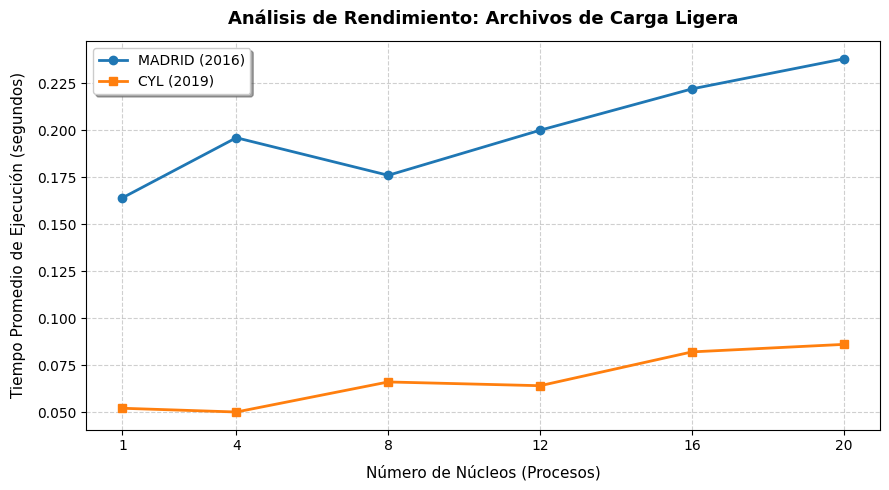

In [46]:
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# GRÁFICA 1: ARCHIVOS PEQUEÑOS (MADRID Y CYL)
# -------------------------------------------------------------------------
plt.figure(figsize=(9, 5))

# Líneas de cada conjunto
plt.plot(nucleos, tiempos_madrid, marker='o', color='#1f77b4', linewidth=2, label='MADRID (2016)')
plt.plot(nucleos, tiempos_cyl, marker='s', color='#ff7f0e', linewidth=2, label='CYL (2019)')

# Ejes y título
plt.title('Análisis de Rendimiento: Archivos de Carga Ligera', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Número de Núcleos (Procesos)', fontsize=11, labelpad=8)
plt.ylabel('Tiempo Promedio de Ejecución (segundos)', fontsize=11, labelpad=8)

# Estilo
plt.xticks(nucleos)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best', frameon=True, shadow=True)
plt.tight_layout()

# Guardar
plt.savefig('grafica_archivos_pequenos.png', dpi=300)
plt.show()

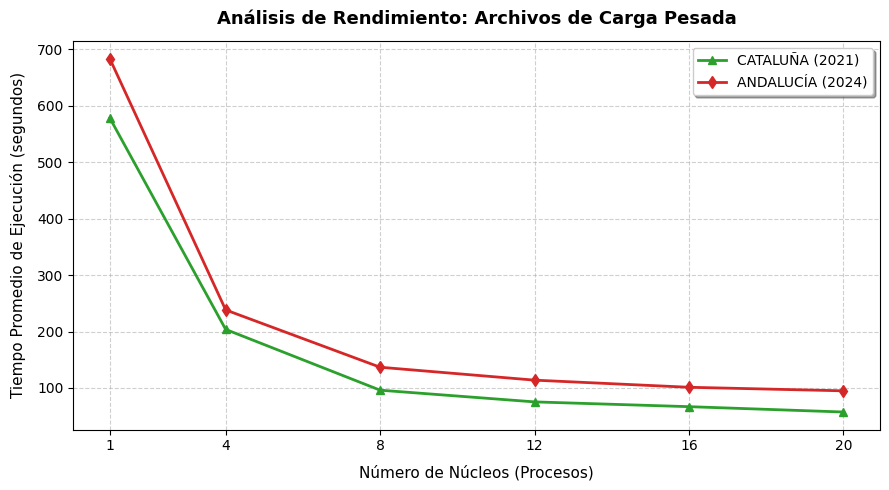

In [47]:
# -------------------------------------------------------------------------
# GRÁFICA 2: ARCHIVOS GRANDES (CATALUÑA Y ANDALUCÍA)
# -------------------------------------------------------------------------

plt.figure(figsize=(9, 5))

# Líneas de cada conjunto
plt.plot(nucleos, tiempos_cataluna, marker='^', color='#2ca02c', linewidth=2, label='CATALUÑA (2021)')
plt.plot(nucleos, tiempos_andalucia, marker='d', color='#d62728', linewidth=2, label='ANDALUCÍA (2024)')

# Ejes y título
plt.title('Análisis de Rendimiento: Archivos de Carga Pesada', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Número de Núcleos (Procesos)', fontsize=11, labelpad=8)
plt.ylabel('Tiempo Promedio de Ejecución (segundos)', fontsize=11, labelpad=8)

# Estilo
plt.xticks(nucleos)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best', frameon=True, shadow=True)
plt.tight_layout()

# Guardar
plt.savefig('grafica_archivos_grandes.png', dpi=300)
plt.show()

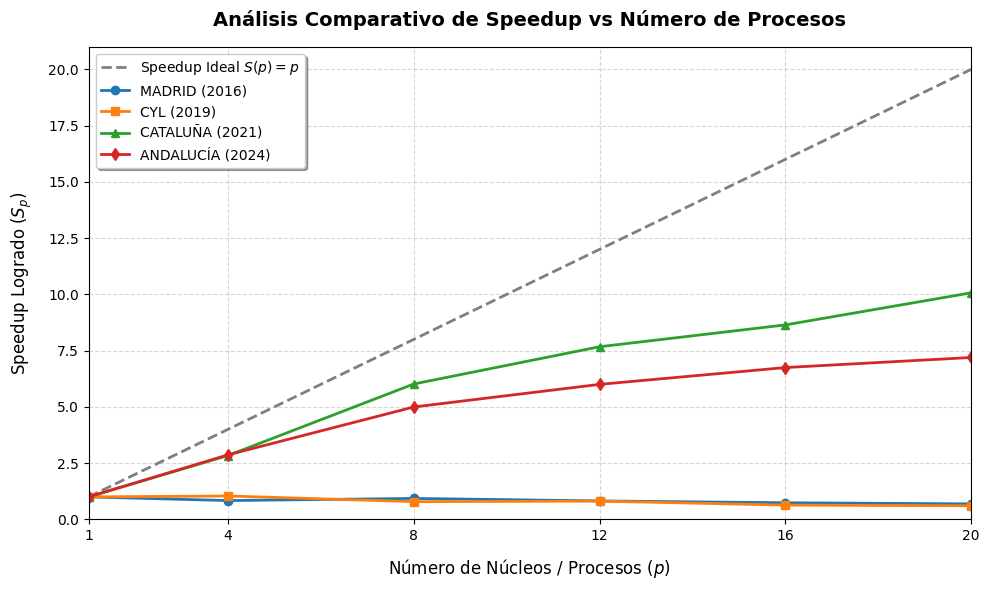

In [48]:
# -------------------------------------------------------------------------
# GRÁFICA: SPEEDUP DE TODOS LOS ARCHIVOS
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Speedup (Sp = T1 / Tp)
speedup_madrid = [tiempos_madrid[0] / tp for tp in tiempos_madrid]
speedup_cyl = [tiempos_cyl[0] / tp for tp in tiempos_cyl]
speedup_cataluna = [tiempos_cataluna[0] / tp for tp in tiempos_cataluna]
speedup_andalucia = [tiempos_andalucia[0] / tp for tp in tiempos_andalucia]

# Curva Ideal de Referencia (Sp = p)
speedup_ideal = [p for p in nucleos]
plt.plot(nucleos, speedup_ideal, linestyle='--', color='#7f7f7f', linewidth=2, label='Speedup Ideal $S(p)=p$')

# Dibujar curvas de cada conjunto de datos
plt.plot(nucleos, speedup_madrid, marker='o', color='#1f77b4', linewidth=2, label='MADRID (2016)')
plt.plot(nucleos, speedup_cyl, marker='s', color='#ff7f0e', linewidth=2, label='CYL (2019)')
plt.plot(nucleos, speedup_cataluna, marker='^', color='#2ca02c', linewidth=2, label='CATALUÑA (2021)')
plt.plot(nucleos, speedup_andalucia, marker='d', color='#d62728', linewidth=2, label='ANDALUCÍA (2024)')

# Títulos y etiquetas
plt.title('Análisis Comparativo de Speedup vs Número de Procesos', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de Núcleos / Procesos ($p$)', fontsize=12, labelpad=10)
plt.ylabel('Speedup Logrado ($S_p$)', fontsize=12, labelpad=10)

# Ajustar ejes
plt.xticks(nucleos)
plt.xlim(1, 20)
plt.ylim(0, 21)

# Cuadrícula y leyenda
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)

# Guardar archivo
plt.tight_layout()
plt.savefig('grafica_speedup.png', dpi=300)
plt.show()